In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

import requests

import warnings
warnings.filterwarnings('ignore')

In [2]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w') as f:
            f.write(response.text)
    else:
        print('Download failed ', response.status_code)

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv'
filename = 'cars_pricing.csv'
download(url, filename)

df = pd.read_csv(filename, header=0)

df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)

df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## Functions for Plotting

In [3]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))
    
    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.legend()
    plt.show()
    plt.close()

In [4]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))
 
    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

## Part 1: Training and Testing

In [5]:
y_data = df['price']
x_data = df.drop('price', axis=1)

Use the function **train_test_split**

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 21
number of training samples: 180


## Task 1:
Use the function **train_test_split** to split up the dataset such that 40% of the data samples will be utilized for testing. Set the parameter **random_state** equal to zero. The output of the function should be the following: "x_train1" , "x_test1", "y_train1" and "y_test1".

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.40, random_state=0)

print('The number of test samples: ', x_test.shape[0])
print('The number of training samples: ', x_train.shape[0])

The number of test samples:  81
The number of training samples:  120


**Create a Linear Regression object**

In [8]:
lr = LinearRegression()

Fit the model using **horsepower**

In [9]:
lr.fit(x_train[['horsepower']], y_train)

LinearRegression()

Let's calculate R^2 score for both training and test data and compare the result

In [10]:
training_score = lr.score(x_train[['horsepower']], y_train)
test_score = lr.score(x_test[['horsepower']], y_test)

print('The R-square score of the training set: ', training_score)
print('The R-square score of the test set: ', test_score)

# The model shows a moderate fit on the training data and performs even better on unseen data. 
# It’s a good sign — the relationship between horsepower and price is fairly well captured.

The R-square score of the training set:  0.5754067463583004
The R-square score of the test set:  0.7139364665406973


## Task 2: Cross-Validation Score
Let's import cross_val_score from the module model_selection.

In [11]:
# cv=4: Determine the number of folds (k)
# The cross validation process runs k times, each time 1 fold is used to test, the rest are used to train

Rcross = cross_val_score(lr, x_data[['horsepower']], y_data, cv=4)
print('The 4 values of Rcross: ', Rcross)

# We can calculate the average and standard deviation of our estimate:
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

# The smaller the mean_square_error, the better the model
# But because sklearn assumes the bigger the better, so we use negative values then multiply with -1
mse = -1 * cross_val_score(lr,x_data[['horsepower']], y_data,cv=4,scoring='neg_mean_squared_error')
print('The 4 MSE values for 4 folds are: ', mse)

The 4 values of Rcross:  [0.7746232  0.51716687 0.74785353 0.04839605]
The mean of the folds are 0.522009915042119 and the standard deviation is 0.29118394447560286
The 4 MSE values for 4 folds are:  [20254142.84026704 43745493.26505169 12539630.34014931 17561927.7224759 ]


## Task 3:
Calculate the average R^2 using two folds, then find the average R^2 for the second fold utilizing the "horsepower" feature:

In [12]:
Rc = cross_val_score(lr, x_data[['horsepower']], y_data, cv=2)
print('The mean of the folds are: ', Rc.mean())

The mean of the folds are:  0.5166761697127429


We can also use **cross_val_predict** to predict the output

In [13]:
yhat = cross_val_predict(lr, x_data[['horsepower']], y_data, cv=4)
yhat[0:5]

array([14141.63807508, 14141.63807508, 20814.29423473, 12745.03562306,
       14762.35027598])

## Overfitting, Underfitting & Model Selection

These problems are more apparent in **Multiple Linear Regression** and **Polynomial Regression** so we will explore overfitting in that context.

Let's create Multiple Linear Regression objects and train the model using **'horsepower', 'curb-weight', 'engine-size' and 'highway-mpg'** as features.

In [14]:
lr = LinearRegression()
lr.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train)

LinearRegression()

**Let's compare the prediction between training set and test set**

In [15]:
# Prediction using training set
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
print('Some prediction values using training set: ', yhat_train[0:4])

# Prediction using test set
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
print('Some prediction values using test set: ', yhat_test[0:4])

Some prediction values using training set:  [38237.3225152   8757.67570728 16832.43125207 16093.28264058]
Some prediction values using test set:  [ 5114.7345989  10941.98915173 20956.19697977 20968.65125706]


## Let's plot the distribution

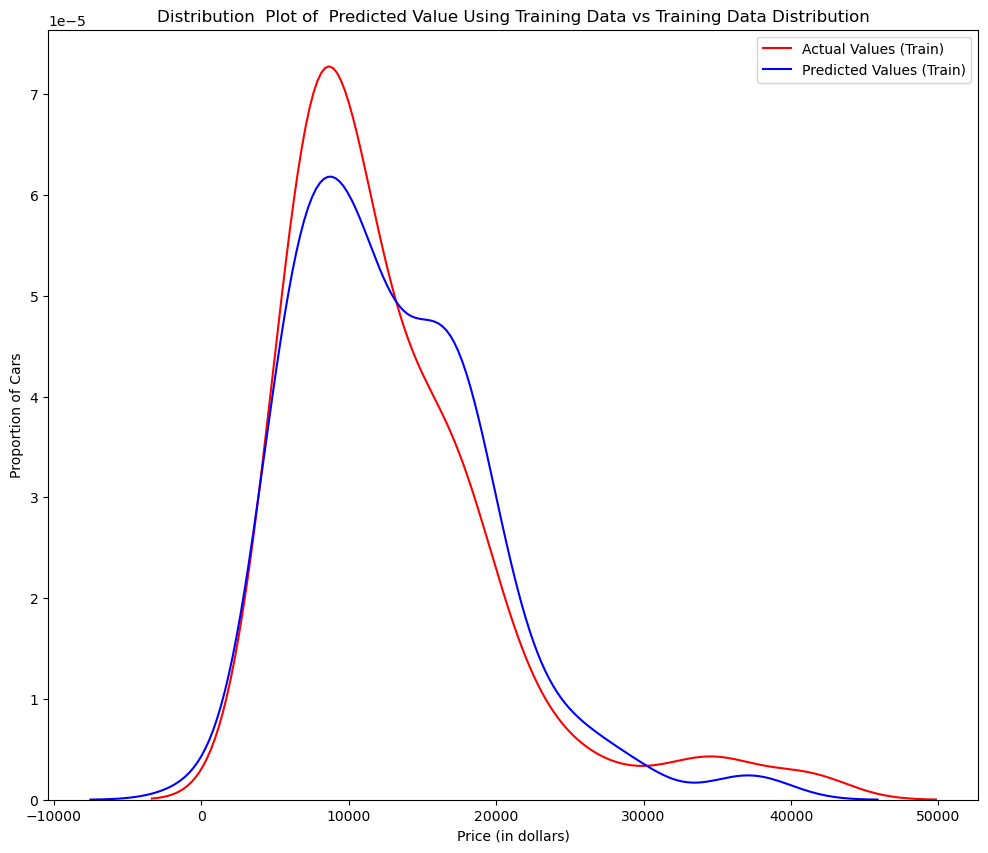

In [16]:
Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (Train)", "Predicted Values (Train)", Title)

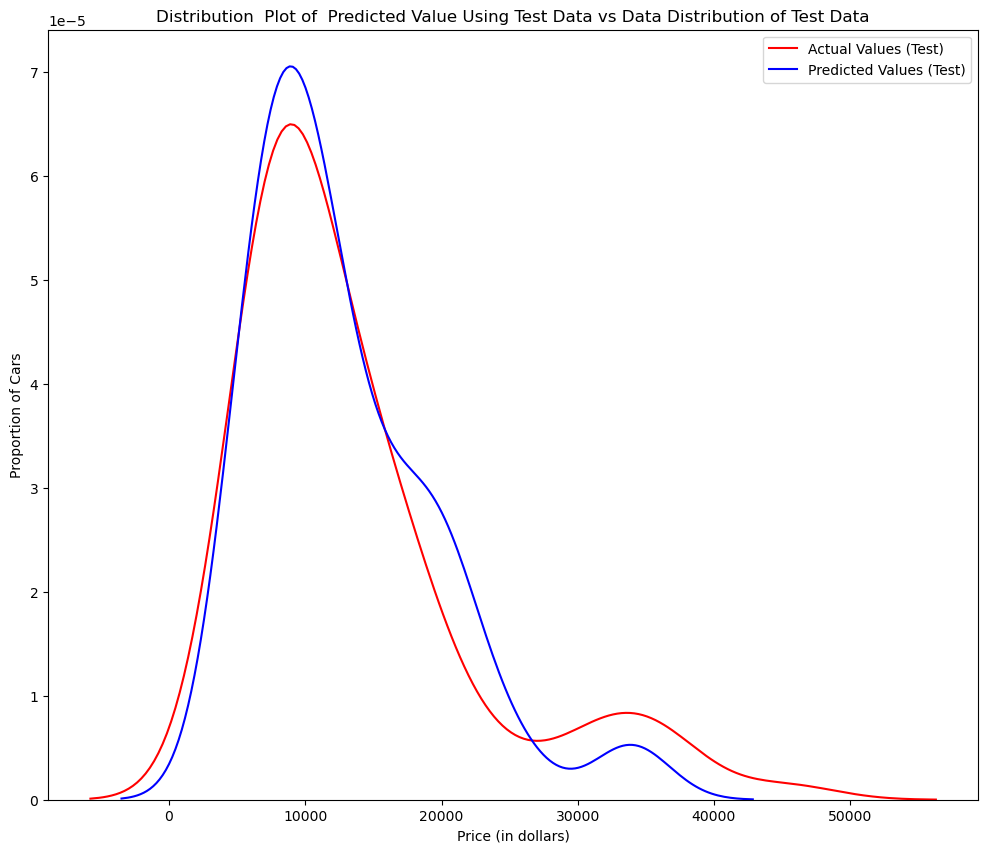

In [17]:
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)","Predicted Values (Test)",Title)

Now let's use 55 percent of the data for training and the rest for testing:

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.45, random_state=0)
pr = PolynomialFeatures(degree=5)
pr

PolynomialFeatures(degree=5)

In [19]:
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.fit_transform(x_test[['horsepower']])

Now, let's create a Linear Regression model **poly** and train it.

In [20]:
poly = LinearRegression()
poly.fit(x_train_pr, y_train)

LinearRegression()

Let's predict the values using the model **poly** we fitted data before

In [21]:
yhat = poly.predict(x_test_pr)


# Let's compare the predicted value with the actual test values

print("Predicted values:", yhat[0:4])
print("True values:", y_test[0:4].values)

Predicted values: [ 6728.58615619  7307.91973653 12213.73734432 18893.37966315]
True values: [ 6295. 10698. 13860. 13499.]


**Use the PollyPlot function to plot the distribution**

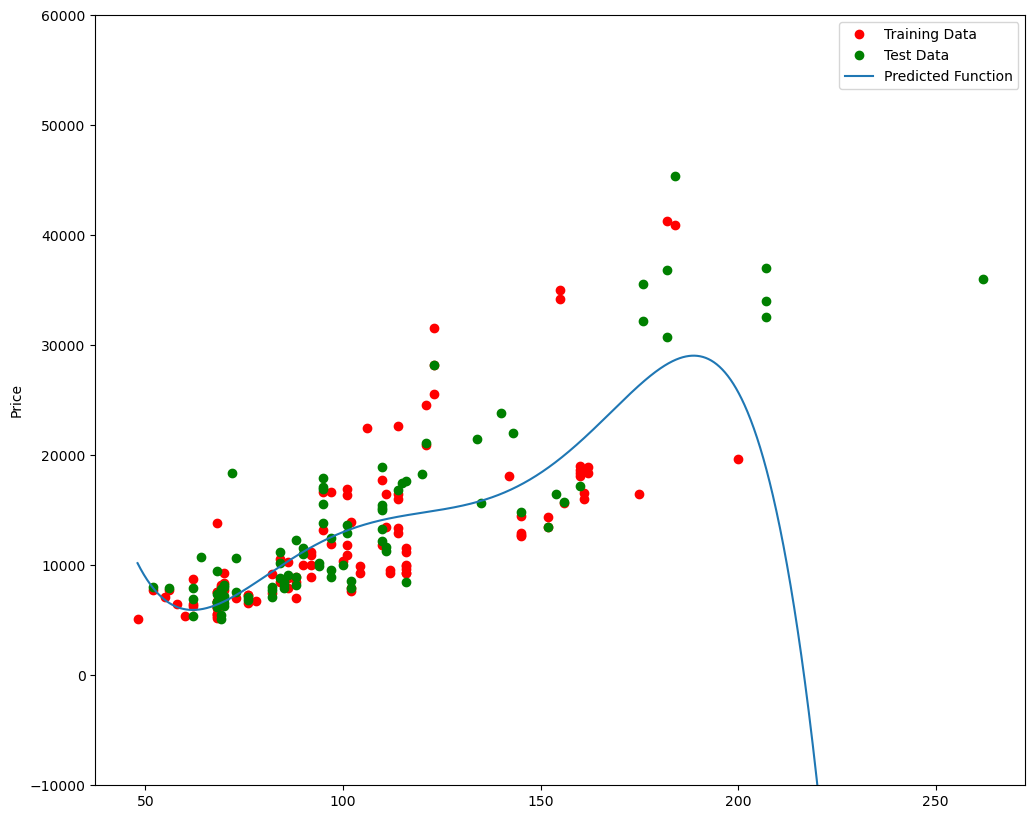

In [22]:
PollyPlot(x_train[['horsepower']], x_test[['horsepower']], y_train, y_test, poly, pr)

**R-square score of training data and test data**

In [23]:
train_score_pr = poly.score(x_train_pr, y_train)
test_score_pr = poly.score(x_test_pr, y_test)

print('The score of training data: ', train_score_pr)
print('The score of test data: ', test_score_pr)

#We see the R^2 for the training data is 0.5567 while the R^2 on the test data was -29.87. 
# The lower the R^2, the worse the model. A negative R^2 is a sign of overfitting.

The score of training data:  0.5567716897727109
The score of test data:  -29.870994900857237


**Let's see how the R^2 changes on the test data for different order polynomials and then plot the results:**

Text(3, 0.75, 'Maximum R^2 ')

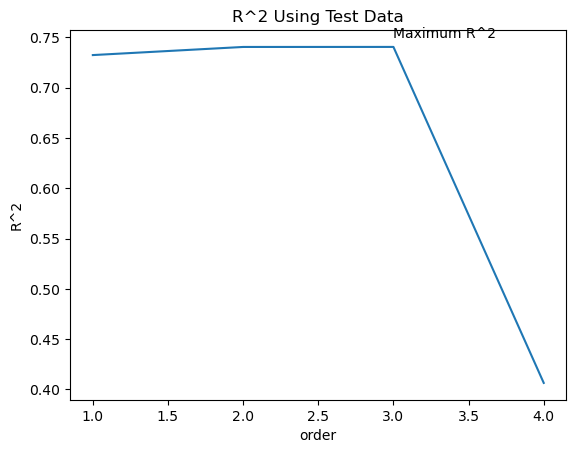

In [24]:
Rsqu_test = []

order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)
    
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    
    x_test_pr = pr.fit_transform(x_test[['horsepower']])    
    
    lr.fit(x_train_pr, y_train)
    
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2 ')    

**We see the R^2 gradually increases until an order three polynomial is used.**
**Then, the R^2 dramatically decreases at an order four polynomial.**

In [25]:
def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)

In [26]:
# Use the interact module to easily test the distibution with different orders and test data proportion

from ipywidgets import interact
interact(f, order=(0, 6, 1), test_data=(0.05, 0.95, 0.05))

interactive(children=(IntSlider(value=3, description='order', max=6), FloatSlider(value=0.45, description='tes…

<function __main__.f(order, test_data)>

## Task 4a: 
Let's perform polynomial transformations with more than one feature. Create a "PolynomialFeatures" object "pr1" of degree two.

In [27]:
pr1 = PolynomialFeatures(degree=2)

## Task 4b: 
Transform the training and testing samples for the features 'horsepower', 'curb-weight', 'engine-size' and 'highway-mpg'. Hint: use the method "fit_transform".

In [28]:
x_train_pr1 = pr1.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_test_pr1 = pr1.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

## Task 4c:
How many dimensions does the new feature have? Hint: use the attribute "shape".

In [29]:
x_train_pr1.shape       # Output: (110, 15)

# 110: number of data samples
# 15: number of features

(110, 15)

## Task 4d:
Create a linear regression model "poly1". Train the object using the method "fit" using the polynomial features.

In [30]:
poly1 = LinearRegression().fit(x_train_pr1, y_train)

## Task 4e:
Use the method "predict" to predict an output on the polynomial features, then use the function "DistributionPlot" to display the distribution of the predicted test output vs. the actual test data.

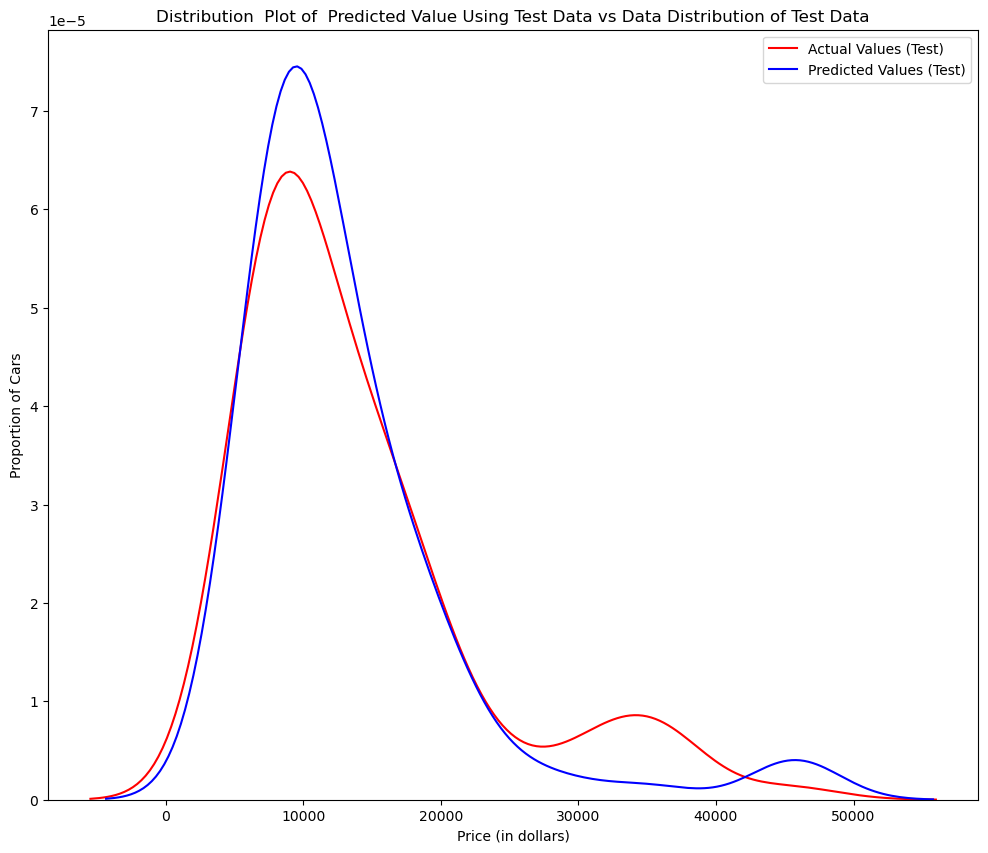

In [31]:
yhat_test1 = poly1.predict(x_test_pr1)


Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'

DistributionPlot(y_test, yhat_test1, "Actual Values (Test)", "Predicted Values (Test)", Title)

## Task 4f:
Using the distribution plot above, describe (in words) the two regions where the predicted prices are less accurate than the actual prices.

In [32]:
description = 'The predicted value is higher than actual value for cars where the price $10,000 range,\n ' \
'conversely the predicted price is lower than the price cost in the $30,000 to $40,000 range.\n ' \
'As such the model is not as accurate in these ranges.'
print(description)

The predicted value is higher than actual value for cars where the price $10,000 range,
 conversely the predicted price is lower than the price cost in the $30,000 to $40,000 range.
 As such the model is not as accurate in these ranges.


## Ridge Regression

Let's perform a degree two polynomial transformation on our data.

In [33]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])
x_test_pr=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])

Let's create a Ridge regression object, setting the regularization parameter (alpha) to 0.1

In [34]:
RidgeModel = Ridge(alpha=1)

Similarly, we can obtain a prediction like normal Linear Regression

In [35]:
print('predicted:', yhat[0:4])
print('test set :', y_test[0:4].values)

predicted: [ 6728.58615619  7307.91973653 12213.73734432 18893.37966315]
test set : [ 6295. 10698. 13860. 13499.]


We select the value of alpha that minimizes the test error. To do so, we can use a for loop. We have also created a progress bar to see how many iterations we have completed so far.

In [36]:
from tqdm import tqdm

Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0,1000))
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:04<00:00, 223.03it/s, Test Score=0.564, Train Score=0.859]


We can plot out the value of R^2 for different alphas:

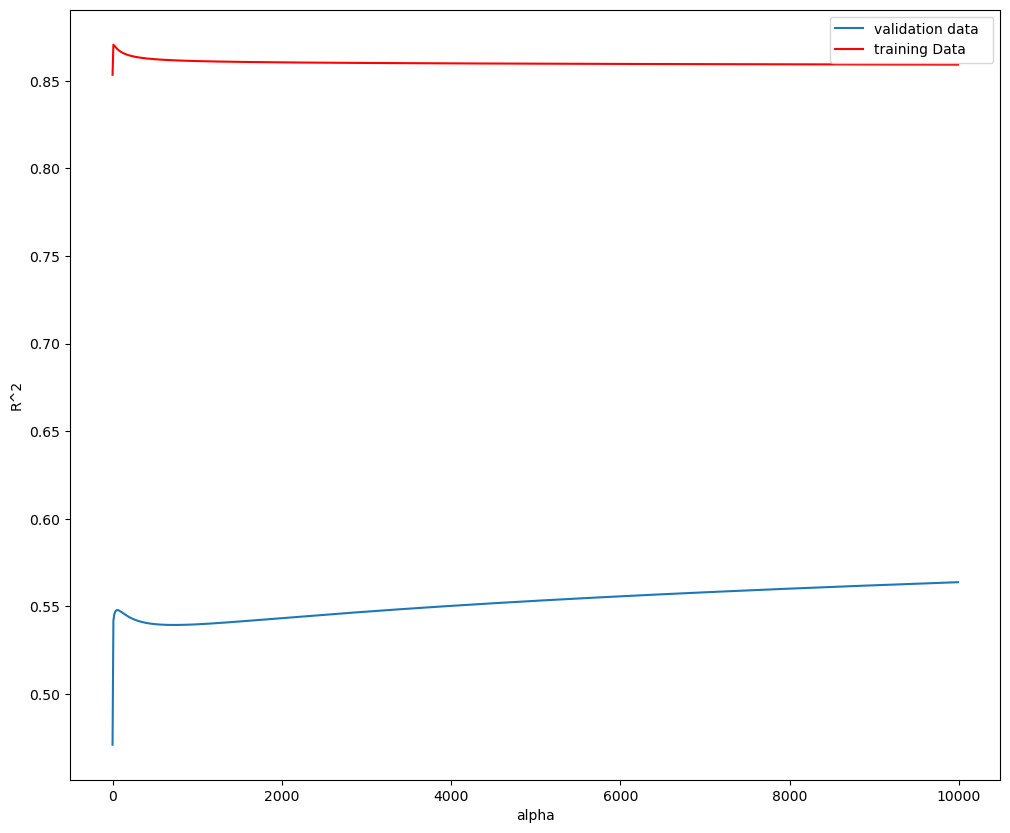

In [37]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

The blue line represents the R^2 of the validation data, and the red line represents the R^2 of the training data. The x-axis represents the different values of Alpha.
Here the model is built and tested on the same data, so the training and test data are the same.

The red line in Figure 4 represents the R^2 of the training data. As alpha increases the R^2 decreases. Therefore, as alpha increases, the model performs worse on the training data

The blue line represents the R^2 on the validation data. As the value for alpha increases, the R^2 increases and converges at a point.

## Task 5:
Perform Ridge regression. Calculate the R^2 using the polynomial features, use the training data to train the model and use the test data to test the model. The parameter alpha should be set to 10.

In [38]:
RidgeModel = Ridge(alpha=10) 
RidgeModel.fit(x_train_pr, y_train)
RidgeModel.score(x_test_pr, y_test)

0.5418576440208525

## Grid Search

The term alpha is a hyperparameter. Sklearn has the class GridSearchCV to make the process of finding the best hyperparameter simpler.

Let's import **GridSearchCV** from the **module model_selection**.

In [ ]:
# We create a dictionary of parameter values:
parameters1 = [{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]

# Create a Ridge regression object:
RR = Ridge()

Dictionary parameters:  [{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]
Ridge regression object:  Ridge()


In [43]:
# Create a ridge grid search object:
Grid1 = GridSearchCV(RR, parameters1, cv=4)

# Fit the model:
Grid1.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])

The object finds the best parameter values on the validation data. We can obtain the estimator with the best parameters and assign it to the variable BestRR as follows:

In [44]:
BestRR = Grid1.best_estimator_
BestRR

Ridge(alpha=10000)

In [45]:
BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test)

0.841164983103615

## Task 6:

Perform a grid search to find the best alpha value and check if using feature scaling improves the model.

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

# Define parameter grid without 'normalize'
parameters2 = [{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]

# Perform Grid Search
Grid2 = GridSearchCV(Ridge(), parameters2, cv=4)
Grid2.fit(x_scaled, y_data)

# Best model
best_ridge_model = Grid2.best_estimator_
best_alpha = Grid2.best_params_['alpha']
best_alpha

100